In [1]:
import torch; torch.set_default_tensor_type(torch.cuda.FloatTensor); import torch.nn as nn; import torch.optim as optim
from gprMax.utilities import detect_check_gpus; from gprMax.gprMax import api; import numpy as np; import h5py; import matplotlib.pyplot as plt; import math
import os; import time; from IPython.display import clear_output; os.getcwd(); import torch; from GPUtil import showUtilization as gpu_usage
from numba import cuda; import gc; import pycuda.driver; import random; import time; import pandas as pd; from scipy.signal import hilbert; import csv
from matplotlib.animation import FuncAnimation; from torch.optim.lr_scheduler import StepLR; from scipy.stats import linregress
plt.rcParams['figure.figsize'] = (10, 2); from bayes_opt import BayesianOptimization; from scipy import stats; import seaborn as sns
def norm(signal):
    signal = np.abs(hilbert(signal))    
    signal = signal/np.max(signal)
    return signal
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


# Data Generation

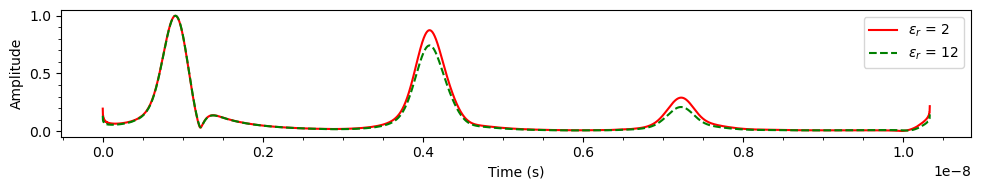

In [ ]:
tw= 10.33e-9;    
def model_miniXT_2D(p1,c1, dep, p2=1.356,c2=0.0012, waveform="gaussian", freq=1.44e9, bs=0.062, dd=0.02):
    b=0.02
    X=0.4; Y=0.5; dx=0.001; Z=dx; gpr_Y = dep+b+dd; freq = freq; Tx=X/2-0.04
    with open("Noise.in", "w") as f:
        f.write(f"#title: Soil_15cm + PEC \n#domain: {X} {Y} {Z}\n#dx_dy_dz: {dx} {dx} {dx}")
        f.write(f"\n#time_window: {tw} \n#material: {p1} {c1} 1 0 mat1 \n#material: {p2} {c2} 1 0 mat2")
        f.write(f"\n#waveform: {waveform} 1 {freq} my_wave")
        f.write(f"\n#hertzian_dipole: z {Tx} {gpr_Y} 0 my_wave\n#rx: {Tx+bs} {gpr_Y} 0")
        f.write(f"\n#box: 0 {b} 0 {X} {dep+b} {Z} mat1")        
        f.write(f"\n#box: 0 {dep+b} 0 {X} {dep+b+2*dd} {Z} mat2")        
        f.write(f"\n#box: 0 {b-.01} 0 {X} {b} {Z} pec")
        f.write(f"\n#geometry_view: 0 0 0 {X} {Y} {Z} {dx} {dx} {dx} Soil n\n")
        f.close()

    api("Noise.in", geometry_only=False, gpu=[0])
    hf2 = h5py.File("Noise.out", 'r', libver='latest', swmr=True)
    Ascan = hf2['rxs/rx1/Ez'][:]
    hf2.close()
    clear_output()
    return Ascan

# PERMITTIVITY variation
sim1 = norm(model_miniXT_2D(p1=10, c1=0.001, dep=0.15));
sim2 = norm(model_miniXT_2D(p1=10, c1=0.01, dep=0.15));

t = np.linspace(0, tw, sim1.shape[0]);  

plt.plot(t,sim1, label=r'$\epsilon_r$ = 2', linestyle='-', color='r')
plt.plot(t,sim2, label=r'$\epsilon_r$ = 12', linestyle='--', color='g')

plt.xlabel('Time (s)'); plt.minorticks_on()
plt.ylabel('Amplitude')
plt.legend(loc='best'); 
plt.tight_layout(); plt.show(); 

In [3]:
p1_values = np.round(np.arange(3.5, 15.1, 0.1),1)
c1_values = np.round(np.arange(0, 0.14, 0.005),3)
dep_values = np.round(np.arange(0.1, 0.25, 0.05),2)

p1_values, c1_values, dep_values, len(p1_values)*len(c1_values)*len(dep_values)

(array([ 3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,  4.5,
         4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,  5.5,  5.6,
         5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,  6.6,  6.7,
         6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,  7.7,  7.8,
         7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,  8.8,  8.9,
         9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9, 10. ,
        10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11. , 11.1,
        11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. , 12.1, 12.2,
        12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1, 13.2, 13.3,
        13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2, 14.3, 14.4,
        14.5, 14.6, 14.7, 14.8, 14.9, 15. ]),
 array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
        0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085,
        0.09 , 0.095, 0.1  , 0.105, 0.11 , 0.115, 0.12 , 0.125, 0.13 ,
 

In [4]:
# Generate simulation data 
# Prepare the data with normalized simulation signals
data = []
scan_num = 0
for p1 in p1_values:
    for c1 in c1_values:
        for dep in dep_values:
            sim_signal = norm(model_miniXT_2D(p1=p1, c1=c1, dep=dep))
            data.append([p1, c1, dep] + list(sim_signal))
            scan_num = scan_num + 1
            print(f'scan number: {scan_num}')

# Save the data to a CSV file
csv_filename = 'FieldTest_1_layer_SimData_1033.csv'
with open(csv_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    # Write the header
    writer.writerow(['p1', 'c1', 'depth'] + [f'sim_{i}' for i in range(len(sim_signal))])
    # Write the data rows
    writer.writerows(data)

pd.read_csv(csv_filename)

scan number: 10092


,p1,c1,depth,sim_0,sim_1,sim_2,sim_3,sim_4,sim_5,sim_6,...,sim_4371,sim_4372,sim_4373,sim_4374,sim_4375,sim_4376,sim_4377,sim_4378,sim_4379,sim_4380
0,3.5,0.000,0.10,0.027043,0.027185,0.027309,0.027441,0.027567,0.027698,0.027826,...,0.025887,0.026000,0.026117,0.026231,0.026348,0.026463,0.026582,0.026696,0.026817,0.026921
1,3.5,0.000,0.15,0.030340,0.030377,0.030501,0.030598,0.030726,0.030837,0.030967,...,0.029018,0.029141,0.029256,0.029384,0.029500,0.029633,0.029751,0.029898,0.030016,0.030221
2,3.5,0.000,0.20,0.030326,0.030618,0.030753,0.030942,0.031079,0.031249,0.031388,...,0.029312,0.029420,0.029546,0.029651,0.029779,0.029876,0.030006,0.030085,0.030217,0.030193
3,3.5,0.005,0.10,0.026856,0.026986,0.027110,0.027237,0.027363,0.027491,0.027618,...,0.025688,0.025801,0.025917,0.026032,0.026149,0.026265,0.026383,0.026500,0.026621,0.026734
4,3.5,0.005,0.15,0.029720,0.029780,0.029907,0.030014,0.030143,0.030261,0.030392,...,0.028397,0.028522,0.028640,0.028768,0.028887,0.029021,0.029142,0.029285,0.029408,0.029596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10087,15.0,0.135,0.15,0.027970,0.028173,0.028293,0.028441,0.028563,0.028702,0.028825,...,0.026976,0.027078,0.027190,0.027290,0.027403,0.027500,0.027615,0.027703,0.027819,0.027852
10088,15.0,0.135,0.20,0.029269,0.029322,0.029442,0.029540,0.029661,0.029770,0.029894,...,0.028009,0.028127,0.028239,0.028360,0.028473,0.028600,0.028715,0.028852,0.028968,0.029151
10089,15.0,0.140,0.10,0.027313,0.027404,0.027523,0.027633,0.027753,0.027869,0.027990,...,0.026136,0.026248,0.026358,0.026473,0.026585,0.026703,0.026816,0.026939,0.027054,0.027197
10090,15.0,0.140,0.15,0.027867,0.028070,0.028189,0.028338,0.028459,0.028598,0.028721,...,0.026879,0.026979,0.027091,0.027191,0.027303,0.027400,0.027514,0.027601,0.027717,0.027749
